#Loading The Dataset

In [4]:
import pandas as pd
df = pd.read_csv("/content/bank-full.csv",sep=";")
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Understand Feature Meaning

In [2]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

**default**			has credit in default?

**balance**     average yearly balance

**housing** 		has housing loan?

**loan**	  	  has personal loan?


**duration**

   last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

**campaign**

number of contacts performed during this campaign and for this client (numeric, includes last contact)

# pdays

number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)

**previous**

	number of contacts performed before this campaign and for this client

**poutcome**

outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

In [3]:
for col in df.columns:
  if df[col].dtype == "object":

    print(df[col].value_counts())
    print("*"*30)


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
******************************
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
******************************
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
******************************
default
no     44396
yes      815
Name: count, dtype: int64
******************************
housing
yes    25130
no     20081
Name: count, dtype: int64
******************************
loan
no     37967
yes     7244
Name: count, dtype: int64
******************************
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
******************************
month
may    13766
ju

In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [6]:
# cols = ["default","housing","loan","y"]
# for col in cols:
#   df[col] = df[col].map({"yes": 1, "no": 0})

# Data Quality


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df['balance'] < 0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
25,44,admin.,married,secondary,no,-372,yes,no,unknown,5,may,172,1,-1,0,unknown,no
28,46,management,single,secondary,no,-246,yes,no,unknown,5,may,255,2,-1,0,unknown,no
36,25,blue-collar,married,secondary,no,-7,yes,no,unknown,5,may,365,1,-1,0,unknown,no
37,53,technician,married,secondary,no,-3,no,no,unknown,5,may,1666,1,-1,0,unknown,no
45,36,admin.,single,primary,no,-171,yes,no,unknown,5,may,242,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44626,31,services,single,secondary,no,-205,no,no,cellular,1,sep,481,1,579,1,failure,yes
44629,28,blue-collar,single,secondary,no,-46,yes,no,cellular,1,sep,199,1,92,14,success,yes
44836,33,blue-collar,married,primary,no,-195,no,no,unknown,20,sep,9,1,-1,0,unknown,no
44908,48,management,divorced,tertiary,no,-130,yes,no,cellular,29,sep,110,2,61,9,failure,no


In [10]:
df[(df['previous'] == 0) & (df['pdays'] != -1)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [11]:
df[df['balance'] < 0]["balance"].describe()

,balance
count,3766.000000
mean,-317.677642
std,368.994983
min,-8019.000000
25%,-422.000000
50%,-230.000000
75%,-93.000000
max,-1.000000


**Logical Inconsistencies**

**persentage of high campaign and y equal yes is 2.45% from the total high campaign**

In [12]:
(df[(df['campaign']>15) & (df['y']=="yes")].shape[0]) /( df[df['campaign']>15].shape[0]) *100

2.4528301886792456

In [13]:
df[df['campaign']>15].sort_values(by="campaign",ascending=False).shape

(530, 17)

In [25]:
df[ (df['job']=="student") & (df['age']>40) ].sort_values(by="age" , ascending=False).shape

(10, 17)

In [15]:
df[df["job"] == "student"]["age"].describe()

,age
count,938.000000
mean,26.542644
std,4.842536
min,18.000000
25%,23.000000
50%,26.000000
75%,29.000000
max,48.000000


In [16]:
df[df["job"] == "student"]["age"].sort_values().unique()

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48])

# Check distribution

**target distribution**

target class unbalanced

In [17]:
per_yes = ( df[df['y']=='yes'].shape[0] / df.shape[0] ) * 100
print(f"Persentage of no = {100-per_yes} %")
print(f"Persentage of yes = {per_yes} %")

Persentage of no = 88.30151954170445 %
Persentage of yes = 11.698480458295547 %


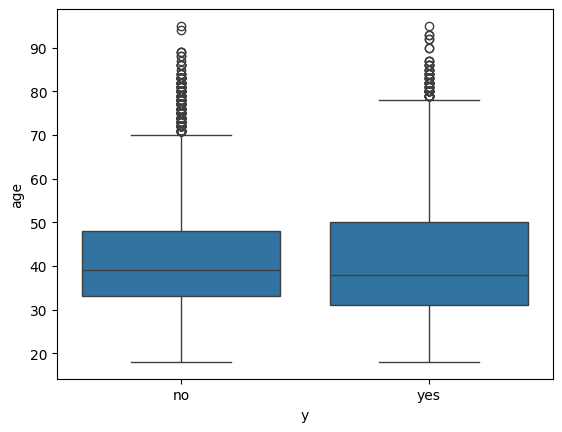

In [20]:
sns.boxplot(data=df, x="y", y="age")
plt.show()

# Categorical features vs target

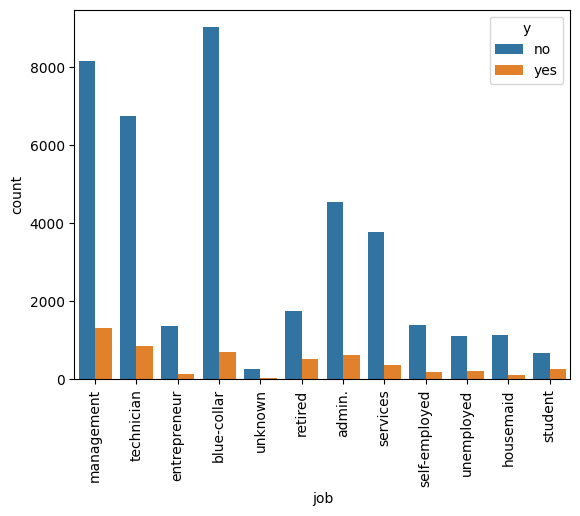

In [21]:
sns.countplot(data=df , x="job" , hue="y")
plt.xticks(rotation=90)
plt.show()

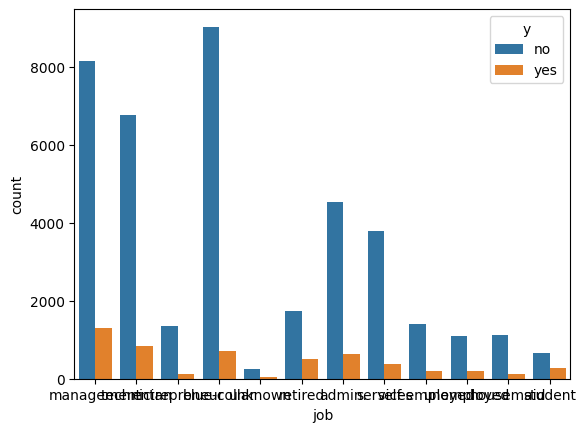

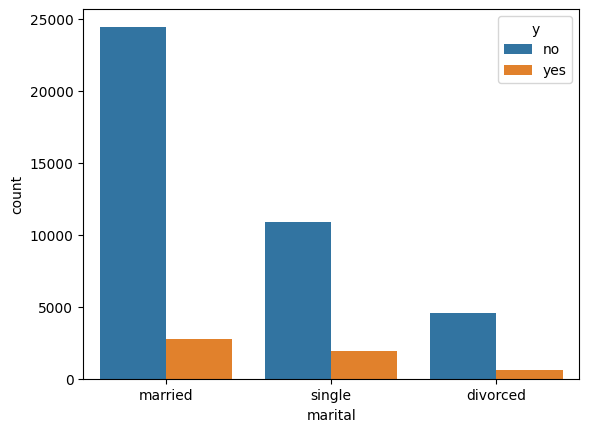

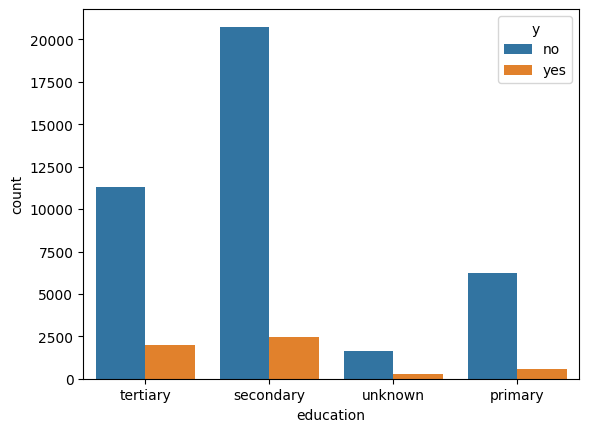

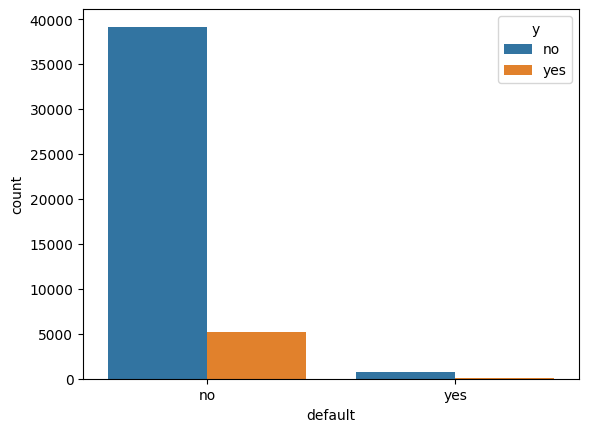

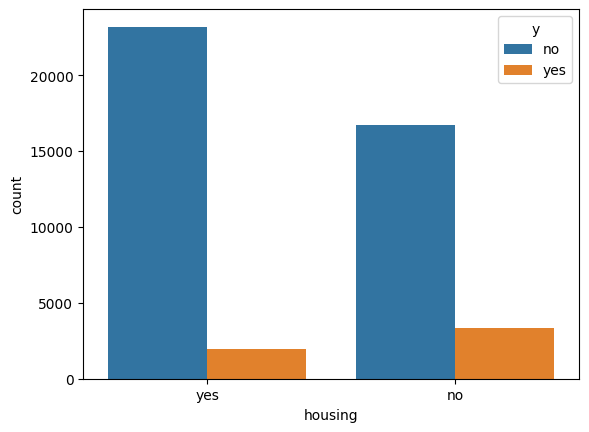

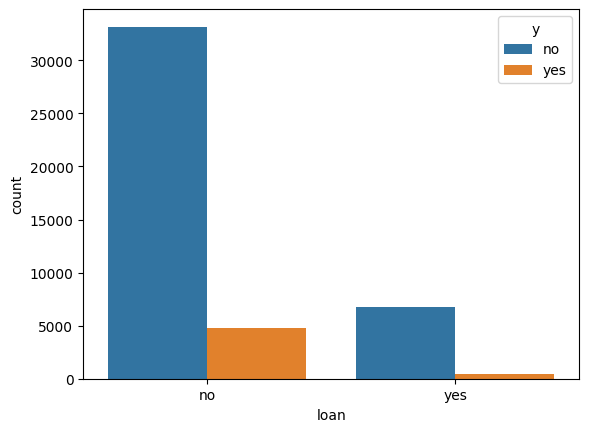

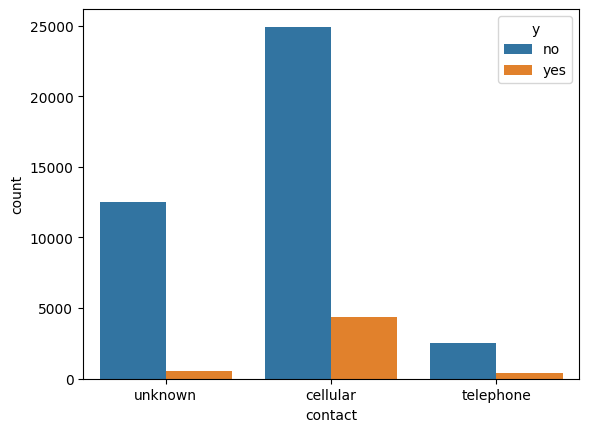

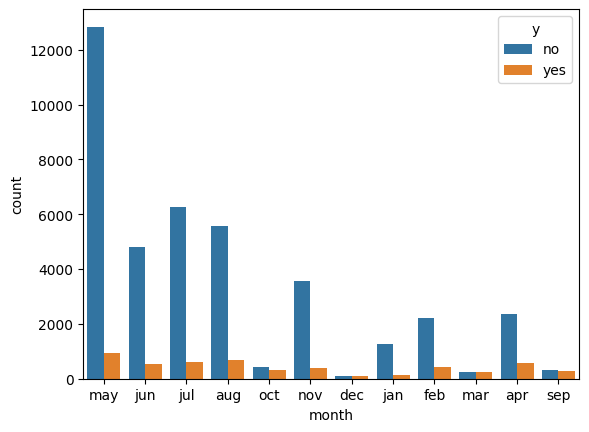

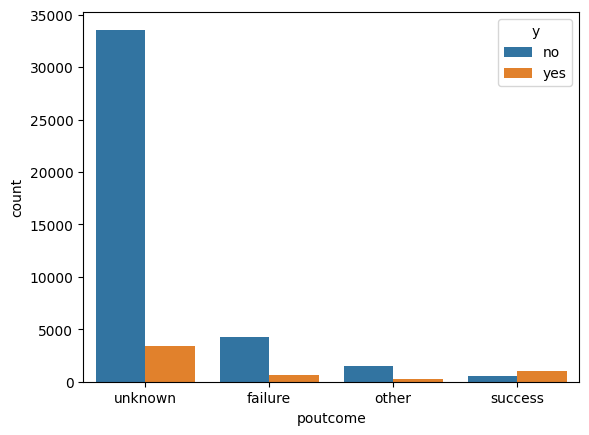

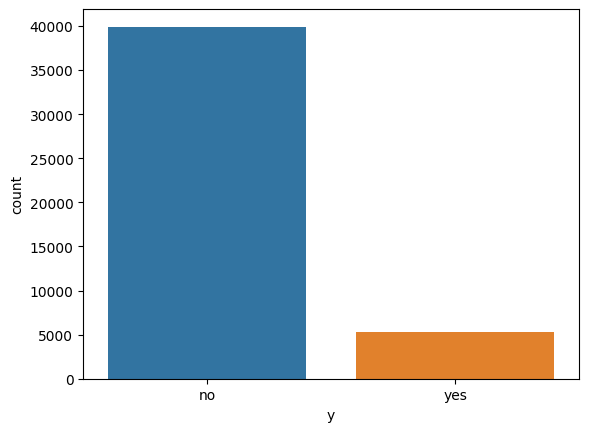

In [92]:
for col in df.select_dtypes(include="object").columns:
  sns.countplot(data=df , x=col , hue='y')

  plt.show()

In [12]:
def get_yes_summary(df, column_name):

    res = pd.crosstab(df[column_name], df["y"])

    res["yes_percentage"] = (
        df.groupby(column_name)["y"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .round(2)
    )


    return res.sort_values(by="yes_percentage", ascending=False)

In [41]:
# pd.crosstab(df['job'], df["housing"])
df[['job','housing','y']]

,job,housing,y
0,management,yes,no
1,technician,yes,no
2,entrepreneur,yes,no
3,blue-collar,yes,no
4,unknown,no,no
...,...,...,...
45206,technician,no,yes
45207,retired,no,yes
45208,retired,no,yes
45209,blue-collar,no,no


In [13]:
get_yes_summary(df,"job")

y,no,yes,yes_percentage
job,,,
student,669,269,28.68
retired,1748,516,22.79
unemployed,1101,202,15.50
management,8157,1301,13.76
admin.,4540,631,12.20
self-employed,1392,187,11.84
unknown,254,34,11.81
technician,6757,840,11.06
services,3785,369,8.88


Distribution of age for students.

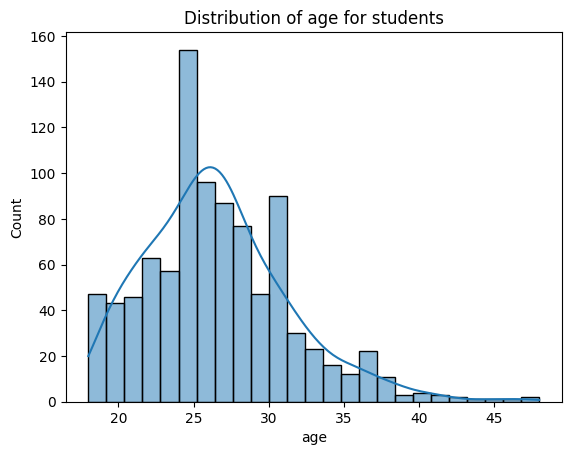

In [48]:
sns.histplot(data=df , x=df[df["job"] == "student"]["age"] , kde=True)
plt.title(f"Distribution of age for students")
plt.xlabel("age")
plt.show()

Number of student which there age more than 30

In [49]:
df[ (df['job']=="student") & (df['age']>30) ].sort_values(by="age" , ascending=False).shape[0]

169

هل الـ older students هم اللي عندهم conversion أعلى، ولا younger students؟

age less than 30 = 221 client is yes , more than 30 = 48 is yes

In [5]:
df[
    (df["job"] == "student") & (df["age"] < 30) & (df["y"] == "yes")
].shape[0]

221

In [7]:
(221 / 769)*100 , (48 / 169)*100

(28.738621586475944, 28.402366863905325)

**Finding**: 169 customers are labeled as student and have age > 30.

**Investigation**: Subscription rates are 28.7% for students ≤30 and 28.4% for students >30.

**Decision**: Retain these records because there is no clear evidence that they represent invalid data.

**marital**

In [14]:
get_yes_summary(df,"marital")

y,no,yes,yes_percentage
marital,,,
single,10878,1912,14.95
divorced,4585,622,11.95
married,24459,2755,10.12


Customers with tertiary education have a higher subscription rate than customers with secondary or primary education.

Unknown education has its own subscription rate and may carry information.

In [15]:
get_yes_summary(df,"education")

y,no,yes,yes_percentage
education,,,
tertiary,11305,1996,15.01
unknown,1605,252,13.57
secondary,20752,2450,10.56
primary,6260,591,8.63


In [24]:
cols = ["default","housing","loan","contact","month"]
for col in cols:
  print(get_yes_summary(df,col))
  print("="*50)

y           no   yes  yes_percentage
default                             
no       39159  5237           11.80
yes        763    52            6.38
y           no   yes  yes_percentage
housing                             
no       16727  3354            16.7
yes      23195  1935             7.7
y        no   yes  yes_percentage
loan                             
no    33162  4805           12.66
yes    6760   484            6.68
y             no   yes  yes_percentage
contact                               
cellular   24916  4369           14.92
telephone   2516   390           13.42
unknown    12490   530            4.07
y         no  yes  yes_percentage
month                            
mar      229  248           51.99
dec      114  100           46.73
sep      310  269           46.46
oct      415  323           43.77
apr     2355  577           19.68
feb     2208  441           16.65
aug     5559  688           11.01
jun     4795  546           10.22
nov     3567  403           10.15

Why does unknown contact have such a low subscription rate?

unknown equal 28 % from the data and only 4.07% is yes

# Multivariant Analysis

job × housing × y

In [48]:
import plotly.express as px

# حساب النسب المئوية
df_pct = df.groupby(['job', 'housing', 'y']).size().unstack(fill_value=0)
df_pct = df_pct.div(df_pct.sum(axis=1), axis=0).reset_index()
df_pct['yes_pct'] = df_pct['yes'] * 100

# رسم الشارت
fig = px.bar(
    df_pct,
    x='yes_pct',
    y='job',
    color='housing',
    barmode='group', # يضع housing=no و housing=yes بجانب بعضهما لكل وظيفة
    orientation='h',
    labels={'yes_pct': 'y = Yes (%)', 'job': 'Job Category', 'housing': 'Housing Loan'},
    title="Success Rate (y=Yes) by Job and Housing Status"
)

fig.show()

In [50]:
import pandas as pd


counts = df.groupby(['job', 'housing']).size().unstack(fill_value=0)
counts.columns = ['housing_no_count', 'housing_yes_count']


yes_target = df[df['y'] == 'yes'].groupby(['job', 'housing']).size().unstack(fill_value=0)


for col in ['no', 'yes']:
    if col not in yes_target.columns:
        yes_target[col] = 0


counts['target_yes_in_housing_no_%'] = (yes_target['no'] / counts['housing_no_count'] * 100).round(2).fillna(0)
counts['target_yes_in_housing_yes_%'] = (yes_target['yes'] / counts['housing_yes_count'] * 100).round(2).fillna(0)


result_table = counts[['housing_no_count', 'housing_yes_count', 'target_yes_in_housing_no_%', 'target_yes_in_housing_yes_%']].reset_index()

result_table = result_table.sort_values(
    by='target_yes_in_housing_no_%',
    ascending=False
)

print(result_table)

              job  housing_no_count  housing_yes_count  \
8         student               689                249   
5         retired              1773                491   
10     unemployed               760                543   
4      management              4780               4678   
0          admin.              1989               3182   
6   self-employed               814                765   
9      technician              3482               4115   
7        services              1388               2766   
11        unknown               262                 26   
2    entrepreneur               618                869   
1     blue-collar              2684               7048   
3       housemaid               842                398   

    target_yes_in_housing_no_%  target_yes_in_housing_yes_%  
8                        35.85                         8.84  
5                        26.17                        10.59  
10                       21.32                         7.37

The relationship between campaign month and subscription rate persists across different contact methods, suggesting that the observed monthly pattern is not fully explained by contact type alone.

In [59]:
import pandas as pd


counts = df.groupby(['month', 'contact']).size().unstack(fill_value=0)

yes_target = df[df['y'] == 'yes'].groupby(['month', 'contact']).size().unstack(fill_value=0)


counts['target_yes_in_cellular_%'] = (yes_target['cellular'] / counts['cellular'] * 100).round(2).fillna(0)
counts['target_yes_in_telephone_%'] = (yes_target['telephone'] / counts['telephone'] * 100).round(2).fillna(0)
counts['target_yes_in_unknown_%'] = (yes_target['unknown'] / counts['unknown'] * 100).round(2).fillna(0)


result_table = counts[['cellular', 'telephone','unknown', 'target_yes_in_cellular_%', 'target_yes_in_telephone_%','target_yes_in_unknown_%']].reset_index()

result_table = result_table.sort_values(
    by='target_yes_in_cellular_%',
    ascending=False
)

print(result_table)

contact month  cellular  telephone  unknown  target_yes_in_cellular_%  \
7         mar       417         53        7                     53.24   
11        sep       466         66       47                     51.72   
2         dec       174         37        3                     49.43   
10        oct       557        131       50                     44.70   
6         jun       729         80     4532                     43.90   
0         apr      2727        199        6                     19.55   
3         feb      2362        274       13                     16.89   
8         may      5331        460     7975                     11.87   
1         aug      5950        246       51                     10.94   
4         jan      1265        129        9                     10.20   
9         nov      3540        379       51                      9.92   
5         jul      5767        852      276                      9.62   

contact  target_yes_in_telephone_%  target_yes_in_

In [90]:
import pandas as pd

def get_yes_summaryy(df, column_name):
    res = pd.crosstab(df[column_name], df["y"])

    res["total_count"] = res.sum(axis=1)

    res["yes_percentage"] = (
        df.groupby(column_name)["y"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .round(2)
    )

    cols = [col for col in res.columns if col not in ["total_count", "yes_percentage"]]
    res = res[cols + ["total_count", "yes_percentage"]]

    return res.sort_values(by="yes_percentage", ascending=False)

In [87]:
res = get_yes_summaryy(df,"previous")
res = res.reset_index()
res

y,previous,no,yes,total_count,yes_percentage
0,0,33570,3384,36954,9.16
1,1,2189,583,2772,21.03
2,2,1650,456,2106,21.65
3,3,848,294,1142,25.74
4,4,543,171,714,23.95
5,5,338,121,459,26.36
6,6,194,83,277,29.96
7,7,151,54,205,26.34
8,8,90,39,129,30.23
9,9,68,24,92,26.09


# Customers with previous contact had a substantially higher subscription rate (23.07%) than customers with no previous contact (9.16%).

In [91]:
get_yes_summaryy(df,'poutcome')

y,no,yes,total_count,yes_percentage
poutcome,,,,
success,533,978,1511,64.73
other,1533,307,1840,16.68
failure,4283,618,4901,12.61
unknown,33573,3386,36959,9.16


**poutcome = unknown , no previous contact**. the same total_count

# Among customers with previous campaign contact, those whose previous campaign outcome was successful had a substantially higher subscription rate in the current campaign (64.73%) compared with customers whose previous outcome was failure (12.61%) or other (16.68%).

In [88]:
import numpy as np
import pandas as pd


res_df = res.reset_index()

res_df['previous_group'] = np.where(res_df['previous'] == 0, '0', 'more thane 0')

summary_grouped = res_df.groupby('previous_group').agg({
    'no': 'sum',
    'yes': 'sum',
    'total_count': 'sum'
}).reset_index()


summary_grouped['yes_percentage'] = (summary_grouped['yes'] / summary_grouped['total_count'] * 100).round(2)


print(summary_grouped)

y previous_group     no   yes  total_count  yes_percentage
0              0  33570  3384        36954            9.16
1   more thane 0   6352  1905         8257           23.07


In [82]:
df[df['previous']> 0 ]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,349,2,262,275,other,no


# Numerical features × target

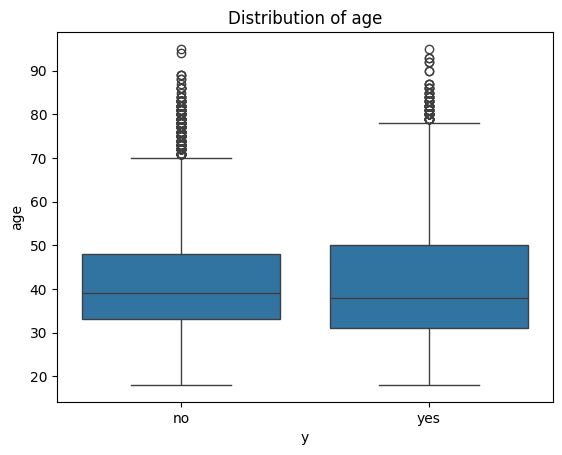

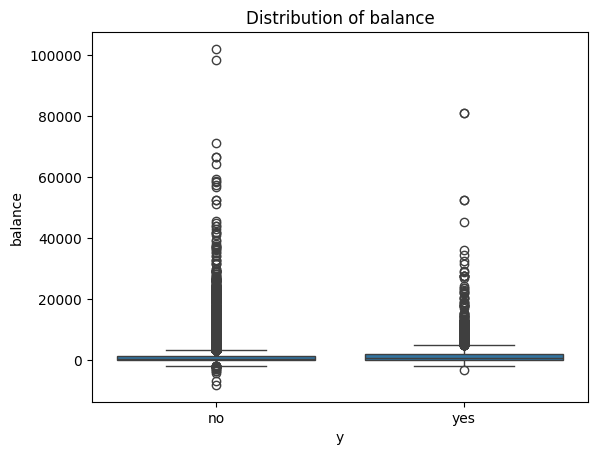

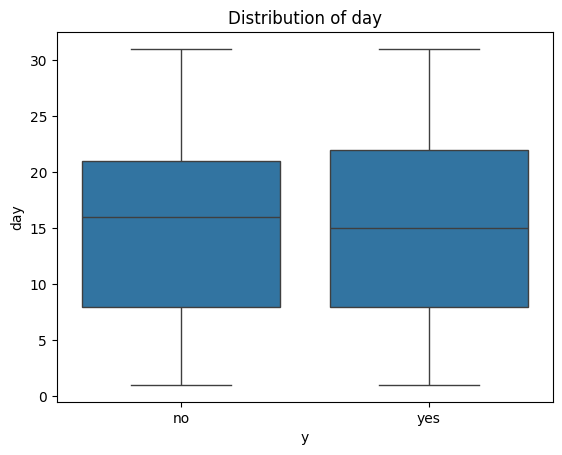

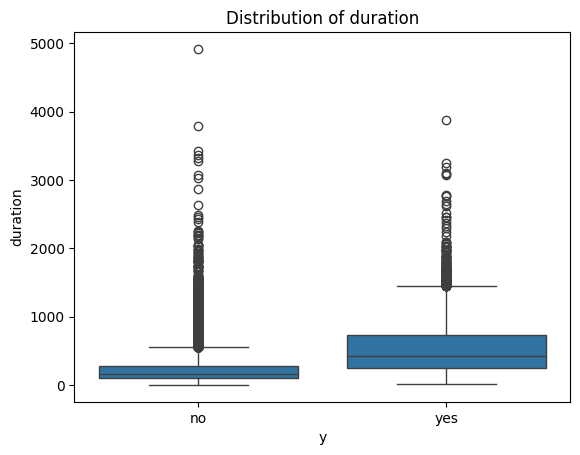

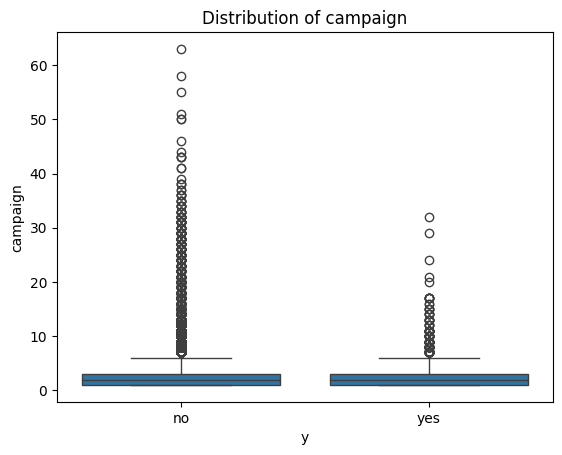

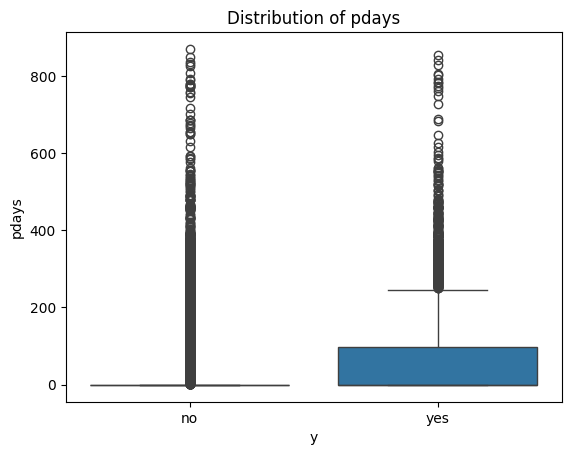

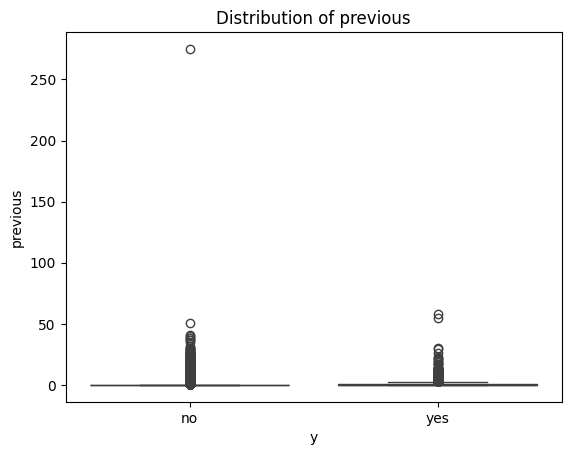

In [99]:
for col in df.select_dtypes(include="number").columns:
  sns.boxplot(data=df, x='y',y=col)
  plt.title(f"Distribution of {col}")
  plt.show()

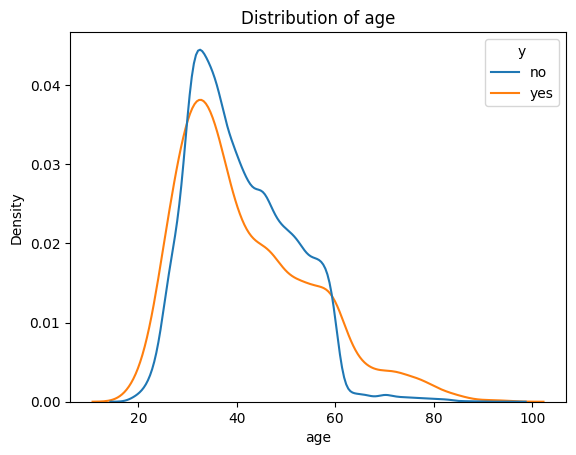

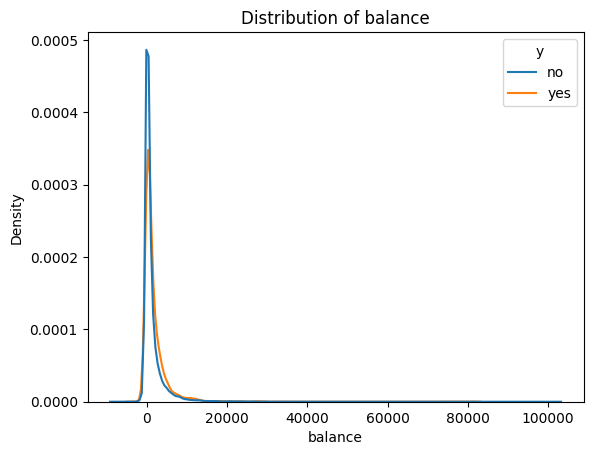

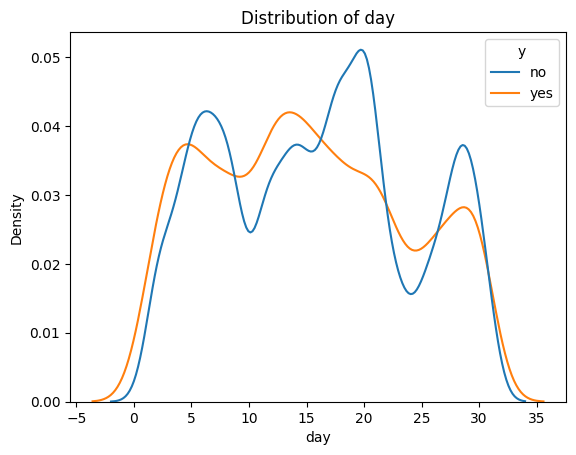

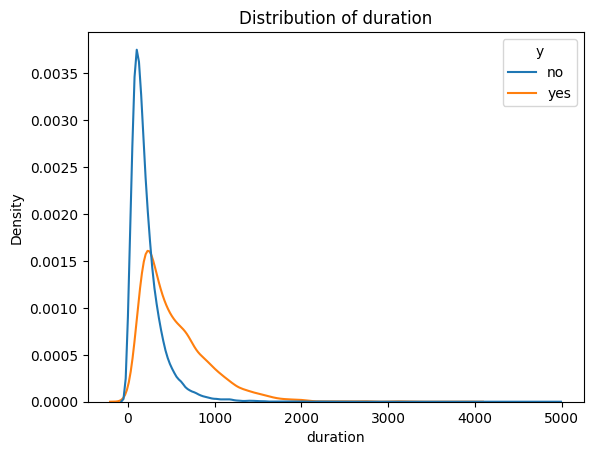

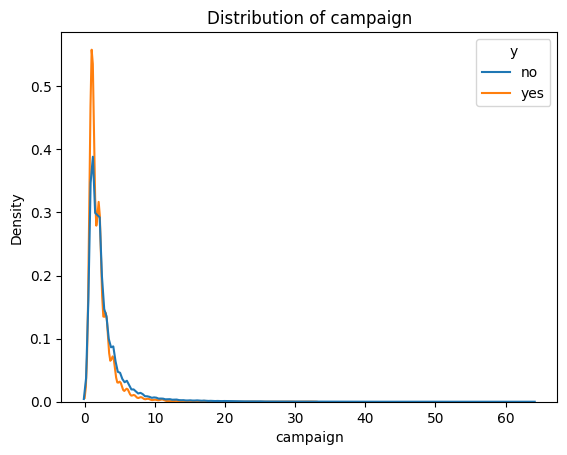

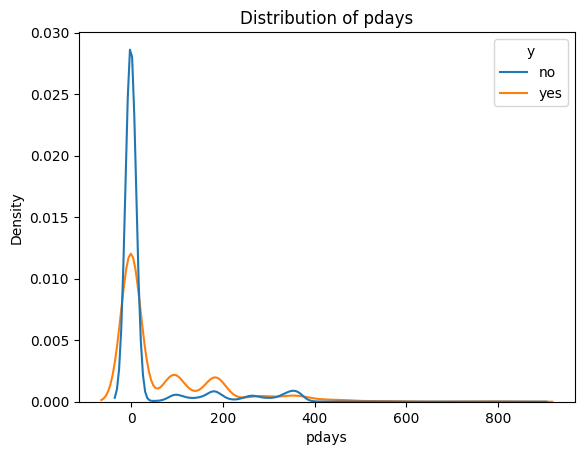

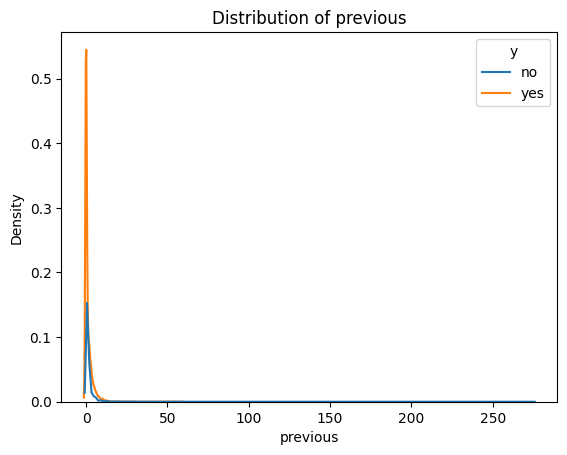

In [96]:
for col in df.select_dtypes(include="number").columns:
  sns.kdeplot(data=df, x=col, hue="y", common_norm=False)
  plt.title(f"Distribution of {col}")
  plt.show()

In [100]:
import pandas as pd
import numpy as np

def analyze_age_conversion(df, age_col='age', target_col='y'):

    bins = [-np.inf, 29, 39, 49, 59, np.inf]
    labels = ['< 30', '30–39', '40–49', '50–59', '60+']

    df_temp = df.copy()

    df_temp['age_group'] = pd.cut(df_temp[age_col], bins=bins, labels=labels)

    res = pd.crosstab(df_temp['age_group'], df_temp[target_col])
    res['total_count'] = res.sum(axis=1)


    res['yes_percentage'] = (res['yes'] / res['total_count'] * 100).round(2)


    return res.reset_index()



In [101]:
analyze_age_conversion(df)

y,age_group,no,yes,total_count,yes_percentage
0,< 30,4345,928,5273,17.60
1,30–39,16176,1913,18089,10.58
2,40–49,10592,1063,11655,9.12
3,50–59,7625,785,8410,9.33
4,60+,1184,600,1784,33.63


In [104]:
labels = ['Bottom 20%', '20–40%', '40–60%', '60–80%', 'Top 20%']
df_copy = df.copy()
df_copy['balance_group'] = pd.qcut(
    df['balance'],
    q=5,
    labels=labels
)

balance_summary = get_yes_summaryy(df_copy, 'balance_group')

balance_summary = balance_summary.reindex(labels)

print(balance_summary)

y                no   yes  total_count  yes_percentage
balance_group                                         
Bottom 20%     8423   630         9053            6.96
20–40%         8154   906         9060           10.00
40–60%         7961  1056         9017           11.71
60–80%         7822  1217         9039           13.46
Top 20%        7562  1480         9042           16.37


/tmp/ipykernel_19864/3555727219.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [107]:
label = ['1','2','3','4-5','6-10','>10']
bin = [0, 1, 2, 3, 5, 10, np.inf]
df_copy['campaign_group'] = pd.cut(df_copy['campaign'], bins=bin, labels=label)
campaign_summary = get_yes_summaryy(df_copy, 'campaign_group')

campaign_summary = campaign_summary.reindex(label)

print(campaign_summary)

y                  no   yes  total_count  yes_percentage
campaign_group                                          
1               14983  2561        17544           14.60
2               11104  1401        12505           11.20
3                4903   618         5521           11.19
4-5              4830   456         5286            8.63
6-10             2953   206         3159            6.52
>10              1149    47         1196            3.93


/tmp/ipykernel_19864/3555727219.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [114]:
df_copy['pdays_group'] = np.where(df_copy['pdays'] == -1, '0', 'more thane 0')

pdays_summary = get_yes_summaryy(df_copy, 'pdays_group')

# pdays_summary = pdays_summary.set_index()

print(pdays_summary)

y                no   yes  total_count  yes_percentage
pdays_group                                           
more thane 0   6352  1905         8257           23.07
0             33570  3384        36954            9.16


Age: non-linear relationship

Balance: positive relationship

Previous contact: strong relationship

Previous outcome: very strong relationship

# start with ML

In [116]:
df = df.drop(columns=['duration','campaign'])


In [119]:
X = df.drop(columns='y')
y = df['y']

In [135]:
y = df['y'].map({'no': 0, 'yes': 1})

In [136]:
from sklearn.model_selection import train_test_split

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 80% of the 80% = 64% Train
# 20% of the 80% = 16% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [121]:
X.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,-1,0,unknown


In [127]:
X['poutcome'].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer


def encode_cyclical_month(df):
    month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
                 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}


    month_nums = df['month'].map(month_map) if 'month' in df.columns else df.iloc[:, 0].map(month_map)

    sin_month = np.sin(2 * np.pi * month_nums / 12)
    cos_month = np.cos(2 * np.pi * month_nums / 12)

    return np.c_[sin_month, cos_month]


binary_cols = ['loan', 'housing', 'default']
ordinal_cols = ['education']
onehot_cols = ['job', 'marital', 'contact', 'poutcome']

binary_categories = [
    ['no', 'yes'],  # loan
    ['no', 'yes'],  # housing
    ['no', 'yes']   # default
]

education_order = [['unknown', 'primary', 'secondary', 'tertiary']]


preprocessor = ColumnTransformer(
    transformers=[

        ('binary', OrdinalEncoder(categories=binary_categories), binary_cols),

        ('ordinal', OrdinalEncoder(categories=education_order), ordinal_cols),

        ('onehot', OneHotEncoder(sparse_output=False), onehot_cols),

        ('cyclical', FunctionTransformer(encode_cyclical_month), ['month'])
    ],
    remainder='passthrough'
)

X_train_prepared = preprocessor.fit_transform(X_train)

X_val_prepared = preprocessor.transform(X_val)

X_test_prepared = preprocessor.transform(X_test)

In [131]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'balance', 'day', 'pdays', 'previous']

preprocessor_LR = ColumnTransformer(
    transformers=[

        ('binary', OrdinalEncoder(categories=binary_categories), binary_cols),

        ('ordinal', OrdinalEncoder(categories=education_order), ordinal_cols),

        ('onehot', OneHotEncoder(sparse_output=False), onehot_cols),

        ('cyclical', FunctionTransformer(encode_cyclical_month), ['month']),

        ('numeric', StandardScaler(), numeric_cols)
    ]
)

X_train_prepared_LR = preprocessor_LR.fit_transform(X_train)

X_val_prepared_LR = preprocessor_LR.transform(X_val)

X_test_prepared_LR = preprocessor_LR.transform(X_test)

In [128]:
X_train_prepared[0] ,X_train_prepared.shape

(array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  3.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  8.66025404e-01,  5.00000000e-01,
         3.80000000e+01,  4.38300000e+03,  4.00000000e+00, -1.00000000e+00,
         0.00000000e+00]),
 (28934, 33))

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve , accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_prepared_LR, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [138]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred):.4f}")
    print(f"Recall   : {recall_score(y, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y, y_prob):.4f}")
    print()
    print(confusion_matrix(y, y_pred))

In [139]:
evaluate_model(
    model,
    X_train_prepared_LR,
    y_train,
    "Training"
)

evaluate_model(
    model,
    X_val_prepared_LR,
    y_val,
    "Validation"
)

--- Training ---
Accuracy : 0.8924
Precision: 0.6604
Recall   : 0.1648
F1 Score : 0.2638
ROC-AUC  : 0.7393

[[25262   287]
 [ 2827   558]]
--- Validation ---
Accuracy : 0.8942
Precision: 0.7015
Recall   : 0.1667
F1 Score : 0.2693
ROC-AUC  : 0.7490

[[6328   60]
 [ 705  141]]


In [141]:
y_prob = model.predict_proba(X_val_prepared_LR)[:, 1]
y_prob

array([0.19500145, 0.16205781, 0.74854045, ..., 0.19025165, 0.04492179,
       0.09937752])

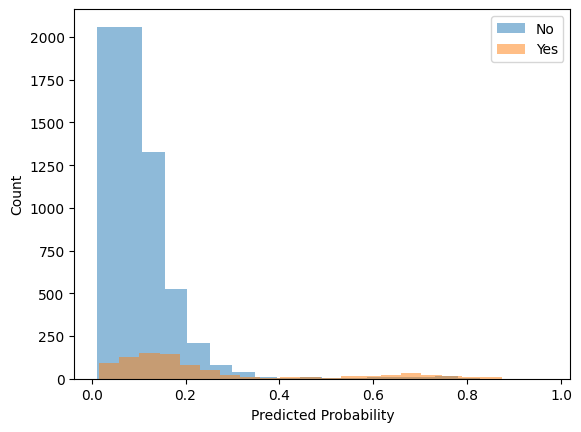

In [142]:
import matplotlib.pyplot as plt

plt.hist(y_prob[y_val == 0], bins=20, alpha=0.5, label='No')
plt.hist(y_prob[y_val == 1], bins=20, alpha=0.5, label='Yes')

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

In [143]:

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_pred_threshold),
        "Recall": recall_score(y_val, y_pred_threshold),
        "F1": f1_score(y_val, y_pred_threshold)
    })

results_df = pd.DataFrame(results)

results_df



,Threshold,Precision,Recall,F1
0,0.5,0.701493,0.166667,0.269341
1,0.4,0.677824,0.191489,0.298618
2,0.3,0.594156,0.216312,0.317158
3,0.2,0.406460,0.356974,0.380113
4,0.1,0.197554,0.744681,0.312268


**Logistic Regression has reasonable ranking ability (ROC-AUC ≈ 0.75), but the default 0.5 threshold produces very low recall. Lowering the threshold improves recall at the cost of precision, highlighting the importance of threshold selection based on business objectives.**

# 1. Random Forest + RandomizedSearchCV

In [145]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=2,
    verbose=1
)

rf_random.fit(X_train_prepared, y_train)

print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 40}

Best CV ROC-AUC:
0.7909930279932277


In [146]:
rf_best = rf_random.best_estimator_

rf_val_prob = rf_best.predict_proba(X_val_prepared)[:, 1]
rf_val_pred = (rf_val_prob >= 0.5).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_val, rf_val_prob))
print("Validation Precision:", precision_score(y_val, rf_val_pred))
print("Validation Recall:", recall_score(y_val, rf_val_pred))
print("Validation F1:", f1_score(y_val, rf_val_pred))

Validation ROC-AUC: 0.8042369632185643
Validation Precision: 0.4317375886524823
Validation Recall: 0.5756501182033097
Validation F1: 0.49341438703140833


In [147]:
import joblib
joblib.dump(rf_random, "random_forest_random_search.pkl")
joblib.dump(rf_random.best_estimator_, "random_forest_best.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")


rf_val_prob = rf_random.best_estimator_.predict_proba(X_val_prepared)[:, 1]

np.save("rf_val_prob.npy", rf_val_prob)

In [148]:
from google.colab import files

files.download("random_forest_random_search.pkl")
files.download("random_forest_best.pkl")
files.download("preprocessor.pkl")
files.download("rf_val_prob.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 0.5]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train_prepared, y_train)

print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.9}

Best CV ROC-AUC:
0.7962740823528444


In [151]:
xgb_best = xgb_random.best_estimator_

xgb_val_prob = xgb_best.predict_proba(X_val_prepared)[:, 1]
xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_val, xgb_val_prob))
print("Validation Precision:", precision_score(y_val, xgb_val_pred))
print("Validation Recall:", recall_score(y_val, xgb_val_pred))
print("Validation F1:", f1_score(y_val, xgb_val_pred))

Validation ROC-AUC: 0.8108485213853991
Validation Precision: 0.6426512968299711
Validation Recall: 0.2635933806146572
Validation F1: 0.3738474434199497


In [152]:

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

# =========================
# Random Forest
# =========================

rf_val_prob = rf_best.predict_proba(X_val_prepared)[:, 1]

rf_results = []

for threshold in thresholds:
    rf_pred = (rf_val_prob >= threshold).astype(int)

    rf_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, rf_pred),
        "Recall": recall_score(y_val, rf_pred),
        "F1": f1_score(y_val, rf_pred)
    })

rf_threshold_df = pd.DataFrame(rf_results)

print("Random Forest:")
display(rf_threshold_df)


Random Forest:


,Threshold,Precision,Recall,F1
0,0.5,0.431738,0.575650,0.493414
1,0.4,0.330394,0.664303,0.441303
2,0.3,0.228966,0.784870,0.354511
3,0.2,0.160463,0.901891,0.272451
4,0.1,0.124493,0.978723,0.220888


In [153]:

# =========================
# XGBoost
# =========================

xgb_val_prob = xgb_best.predict_proba(X_val_prepared)[:, 1]

xgb_results = []

for threshold in thresholds:
    xgb_pred = (xgb_val_prob >= threshold).astype(int)

    xgb_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, xgb_pred),
        "Recall": recall_score(y_val, xgb_pred),
        "F1": f1_score(y_val, xgb_pred)
    })

xgb_threshold_df = pd.DataFrame(xgb_results)

print("XGBoost:")
display(xgb_threshold_df)

XGBoost:


,Threshold,Precision,Recall,F1
0,0.5,0.642651,0.263593,0.373847
1,0.4,0.608871,0.356974,0.450075
2,0.3,0.519945,0.446809,0.480610
3,0.2,0.457031,0.553191,0.500535
4,0.1,0.292135,0.706856,0.413412


In [154]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.51, 0.01)

results = []

for model_name, y_prob in [
    ("Random Forest", rf_val_prob),
    ("XGBoost", xgb_val_prob)
]:

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)

        results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,Model,Threshold,Precision,Recall,F1
0,Random Forest,0.05,0.117393,0.996454,0.210041
1,Random Forest,0.06,0.118342,0.995272,0.211531
2,Random Forest,0.07,0.119403,0.992908,0.213171
3,Random Forest,0.08,0.120832,0.989362,0.215361
4,Random Forest,0.09,0.122755,0.985816,0.218325


In [155]:
best_thresholds = (
    threshold_results
    .loc[
        threshold_results
        .groupby("Model")["F1"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

best_thresholds

,Model,Threshold,Precision,Recall,F1
0,Random Forest,0.50,0.431738,0.575650,0.493414
1,XGBoost,0.22,0.475891,0.536643,0.504444


In [156]:
threshold_results[
    threshold_results["Model"] == "Random Forest"
].sort_values("F1", ascending=False).head(10)

,Model,Threshold,Precision,Recall,F1
45,Random Forest,0.50,0.431738,0.575650,0.493414
44,Random Forest,0.49,0.421008,0.582742,0.488845
43,Random Forest,0.48,0.411138,0.593381,0.485728
42,Random Forest,0.47,0.401899,0.600473,0.481517
41,Random Forest,0.46,0.390281,0.607565,0.475266
40,Random Forest,0.45,0.381818,0.620567,0.472760
39,Random Forest,0.44,0.372535,0.625296,0.466902
38,Random Forest,0.43,0.364801,0.639480,0.464577
37,Random Forest,0.42,0.353925,0.650118,0.458333
36,Random Forest,0.41,0.342381,0.656028,0.449939


In [157]:
threshold_results[
    threshold_results["Model"] == "XGBoost"
].sort_values("F1", ascending=False).head(10)

,Model,Threshold,Precision,Recall,F1
63,XGBoost,0.22,0.475891,0.536643,0.504444
62,XGBoost,0.21,0.466734,0.547281,0.503808
64,XGBoost,0.23,0.483660,0.524823,0.503401
60,XGBoost,0.19,0.450611,0.566194,0.501833
61,XGBoost,0.20,0.457031,0.553191,0.500535
59,XGBoost,0.18,0.442325,0.575650,0.500257
65,XGBoost,0.24,0.487035,0.510638,0.498557
58,XGBoost,0.17,0.428448,0.587470,0.495513
66,XGBoost,0.25,0.491269,0.498818,0.495015
67,XGBoost,0.26,0.500000,0.486998,0.493413


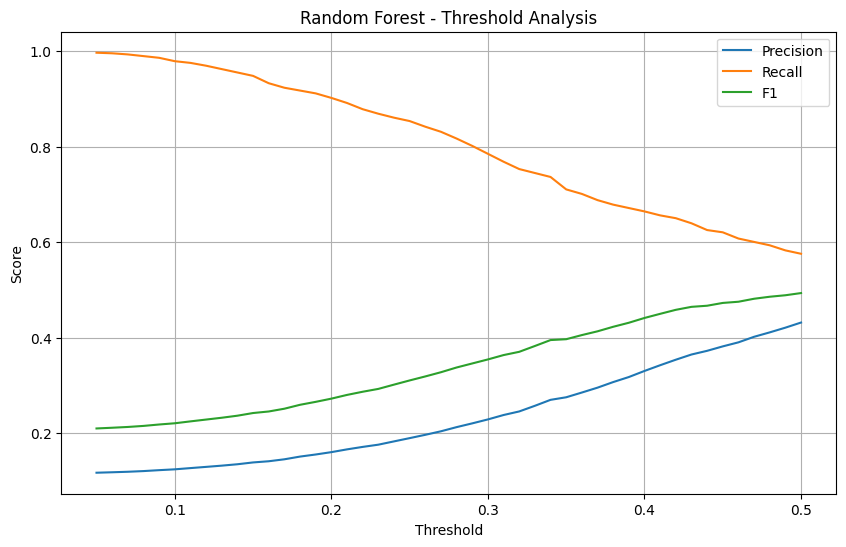

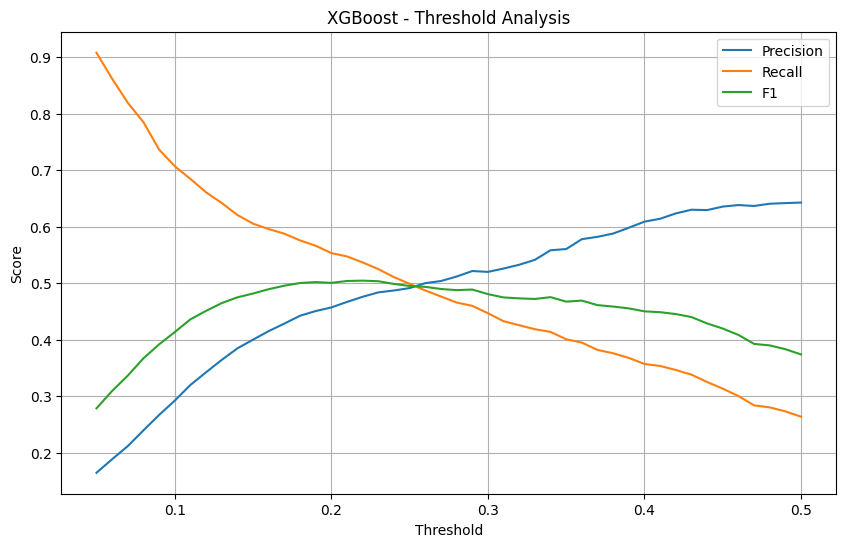

In [158]:
import matplotlib.pyplot as plt

for model_name in ["Random Forest", "XGBoost"]:

    model_results = threshold_results[
        threshold_results["Model"] == model_name
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        model_results["Threshold"],
        model_results["Precision"],
        label="Precision"
    )

    plt.plot(
        model_results["Threshold"],
        model_results["Recall"],
        label="Recall"
    )

    plt.plot(
        model_results["Threshold"],
        model_results["F1"],
        label="F1"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{model_name} - Threshold Analysis")
    plt.legend()
    plt.grid()
    plt.show()

In [159]:
rf_best_threshold = best_thresholds.loc[
    best_thresholds["Model"] == "Random Forest",
    "Threshold"
].iloc[0]

xgb_best_threshold = best_thresholds.loc[
    best_thresholds["Model"] == "XGBoost",
    "Threshold"
].iloc[0]

print("RF threshold:", rf_best_threshold)
print("XGB threshold:", xgb_best_threshold)

RF threshold: 0.5000000000000001
XGB threshold: 0.22000000000000003


In [160]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

models_prob = {
    "Random Forest": rf_val_prob,
    "XGBoost": xgb_val_prob
}

for model_name, y_prob in models_prob.items():

    precision, recall, thresholds = precision_recall_curve(
        y_val,
        y_prob
    )

    pr_auc = average_precision_score(
        y_val,
        y_prob
    )

    print(f"{model_name} PR-AUC: {pr_auc:.4f}")

Random Forest PR-AUC: 0.4557
XGBoost PR-AUC: 0.4771


In [161]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Final model and threshold
final_model = xgb_best
final_threshold = 0.22

# Probability of positive class
y_test_prob = final_model.predict_proba(X_test_prepared)[:, 1]

# Convert probabilities to predictions
y_test_pred = (y_test_prob >= final_threshold).astype(int)

In [162]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")

Accuracy  : 0.8769
Precision : 0.4752
Recall    : 0.4972
F1 Score  : 0.4859
ROC-AUC   : 0.8053
PR-AUC    : 0.4601


In [166]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.93      0.93      0.93      7985
         Yes       0.48      0.50      0.49      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



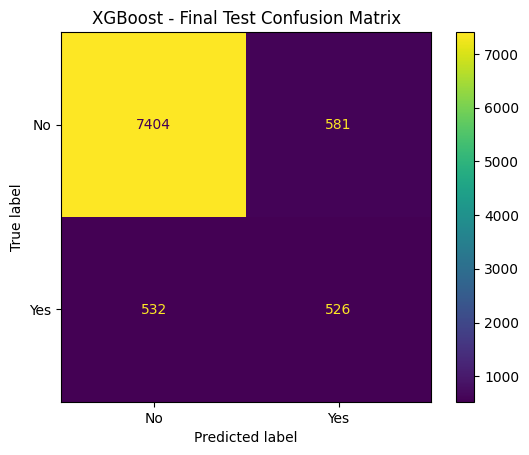

In [167]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot()

plt.title("XGBoost - Final Test Confusion Matrix")
plt.show()

In [171]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm)

[[7404  581]
 [ 532  526]]


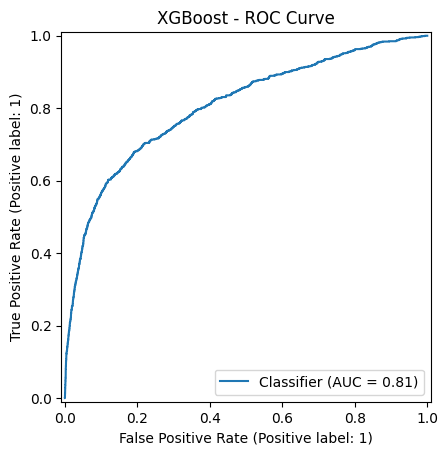

In [168]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("XGBoost - ROC Curve")
plt.show()

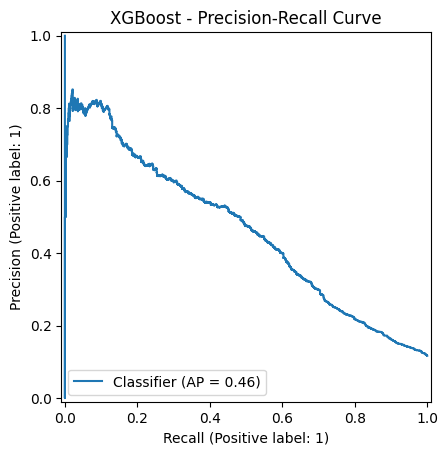

In [169]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("XGBoost - Precision-Recall Curve")
plt.show()

In [170]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc
    ]
})

final_results

,Metric,Test
0,Accuracy,0.876921
1,Precision,0.475158
2,Recall,0.497164
3,F1,0.485912
4,ROC-AUC,0.805274
5,PR-AUC,0.460124


In [172]:
import pandas as pd
import numpy as np

# Create dataframe for test customers
lift_df = pd.DataFrame({
    "actual": y_test.values,
    "probability": y_test_prob
})

# Sort customers by predicted probability
lift_df = lift_df.sort_values(
    "probability",
    ascending=False
).reset_index(drop=True)

# Create 10 equal-sized groups
lift_df["decile"] = pd.qcut(
    lift_df.index,
    q=10,
    labels=False
) + 1

# Calculate metrics for each decile
lift_table = (
    lift_df
    .groupby("decile")
    .agg(
        customers=("actual", "count"),
        actual_yes=("actual", "sum"),
        avg_probability=("probability", "mean")
    )
    .reset_index()
)

# Conversion rate inside each decile
lift_table["conversion_rate"] = (
    lift_table["actual_yes"] /
    lift_table["customers"]
)

# Baseline conversion rate
baseline_rate = y_test.mean()

# Lift
lift_table["lift"] = (
    lift_table["conversion_rate"] /
    baseline_rate
)

# Cumulative calculations
lift_table["cumulative_customers"] = (
    lift_table["customers"].cumsum()
)

lift_table["cumulative_yes"] = (
    lift_table["actual_yes"].cumsum()
)

lift_table["cumulative_conversion_rate"] = (
    lift_table["cumulative_yes"] /
    lift_table["cumulative_customers"]
)

# Cumulative gain
lift_table["gain"] = (
    lift_table["cumulative_yes"] /
    y_test.sum()
)

lift_table

,decile,customers,actual_yes,avg_probability,conversion_rate,lift,cumulative_customers,cumulative_yes,cumulative_conversion_rate,gain
0,1,905,476,0.512535,0.525967,4.495575,905,476,0.525967,0.449905
1,2,904,181,0.186050,0.200221,1.711343,1809,657,0.363184,0.620983
2,3,904,98,0.110547,0.108407,0.926583,2713,755,0.278290,0.713611
3,4,904,73,0.085526,0.080752,0.690210,3617,828,0.228919,0.782609
4,5,905,56,0.070387,0.061878,0.528891,4522,884,0.195489,0.835539
5,6,904,51,0.058795,0.056416,0.482202,5426,935,0.172318,0.883743
6,7,904,33,0.048746,0.036504,0.312013,6330,968,0.152923,0.914934
7,8,904,40,0.039798,0.044248,0.378197,7234,1008,0.139342,0.952741
8,9,904,33,0.031149,0.036504,0.312013,8138,1041,0.127918,0.983932
9,10,905,17,0.020471,0.018785,0.160556,9043,1058,0.116997,1.000000


In [173]:
lift_table_display = lift_table.copy()

lift_table_display["conversion_rate"] *= 100
lift_table_display["cumulative_conversion_rate"] *= 100
lift_table_display["gain"] *= 100

lift_table_display["avg_probability"] *= 100

lift_table_display

,decile,customers,actual_yes,avg_probability,conversion_rate,lift,cumulative_customers,cumulative_yes,cumulative_conversion_rate,gain
0,1,905,476,51.253517,52.596685,4.495575,905,476,52.596685,44.990548
1,2,904,181,18.604979,20.022124,1.711343,1809,657,36.318408,62.098299
2,3,904,98,11.054674,10.840708,0.926583,2713,755,27.828972,71.361059
3,4,904,73,8.552604,8.075221,0.690210,3617,828,22.891899,78.260870
4,5,905,56,7.038712,6.187845,0.528891,4522,884,19.548872,83.553875
5,6,904,51,5.879468,5.641593,0.482202,5426,935,17.231847,88.374291
6,7,904,33,4.874620,3.650442,0.312013,6330,968,15.292259,91.493384
7,8,904,40,3.979829,4.424779,0.378197,7234,1008,13.934200,95.274102
8,9,904,33,3.114864,3.650442,0.312013,8138,1041,12.791841,98.393195
9,10,905,17,2.047066,1.878453,0.160556,9043,1058,11.699657,100.000000


In [174]:
top_k_results = []

for k in [10, 20, 30, 40, 50]:

    n_customers = int(len(lift_df) * k / 100)

    selected = lift_df.iloc[:n_customers]

    actual_yes = selected["actual"].sum()
    conversion_rate = selected["actual"].mean()

    gain = actual_yes / y_test.sum()
    lift = conversion_rate / baseline_rate

    top_k_results.append({
        "Top % Customers": k,
        "Customers Targeted": n_customers,
        "Actual Subscribers": int(actual_yes),
        "Conversion Rate": conversion_rate,
        "Lift": lift,
        "Gain": gain
    })

top_k_table = pd.DataFrame(top_k_results)

top_k_table

,Top % Customers,Customers Targeted,Actual Subscribers,Conversion Rate,Lift,Gain
0,10,904,475,0.525442,4.491093,0.448960
1,20,1808,657,0.363385,3.105945,0.620983
2,30,2712,755,0.278392,2.379491,0.713611
3,40,3617,828,0.228919,1.956630,0.782609
4,50,4521,884,0.195532,1.671262,0.835539


In [180]:
top_k_display = top_k_table.copy()

top_k_display["Conversion Rate"] *= 100
top_k_display["Gain"] *= 100

top_k_display

,Top % Customers,Customers Targeted,Actual Subscribers,Conversion Rate,Lift,Gain
0,10,904,475,52.544248,4.491093,44.896030
1,20,1808,657,36.338496,3.105945,62.098299
2,30,2712,755,27.839233,2.379491,71.361059
3,40,3617,828,22.891899,1.956630,78.260870
4,50,4521,884,19.553196,1.671262,83.553875


In [181]:
print(f"Baseline conversion rate: {baseline_rate:.4f}")
print(f"Baseline conversion rate: {baseline_rate * 100:.2f}%")

Baseline conversion rate: 0.1170
Baseline conversion rate: 11.70%


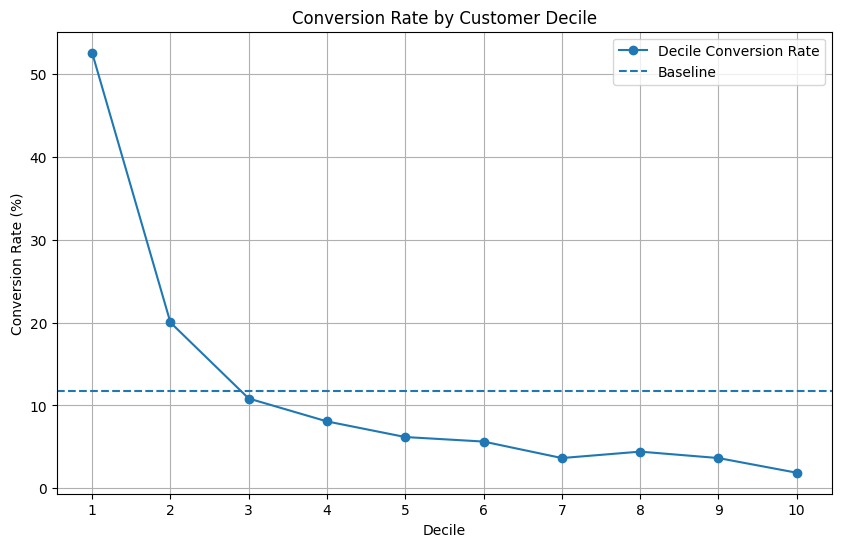

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    lift_table["decile"],
    lift_table["conversion_rate"] * 100,
    marker="o",
    label="Decile Conversion Rate"
)

plt.axhline(
    baseline_rate * 100,
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Decile")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Customer Decile")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

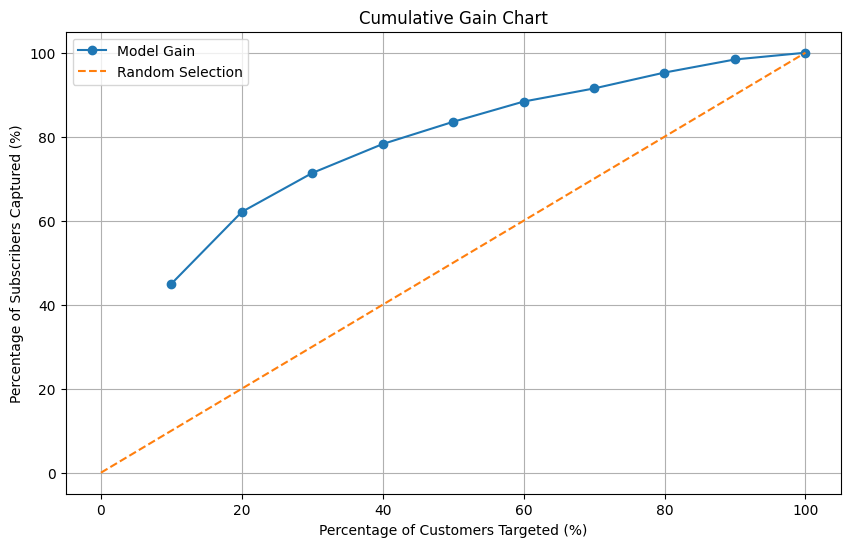

In [178]:
plt.figure(figsize=(10, 6))

plt.plot(
    lift_table["cumulative_customers"] / len(y_test) * 100,
    lift_table["gain"] * 100,
    marker="o",
    label="Model Gain"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random Selection"
)

plt.xlabel("Percentage of Customers Targeted (%)")
plt.ylabel("Percentage of Subscribers Captured (%)")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.grid()
plt.show()

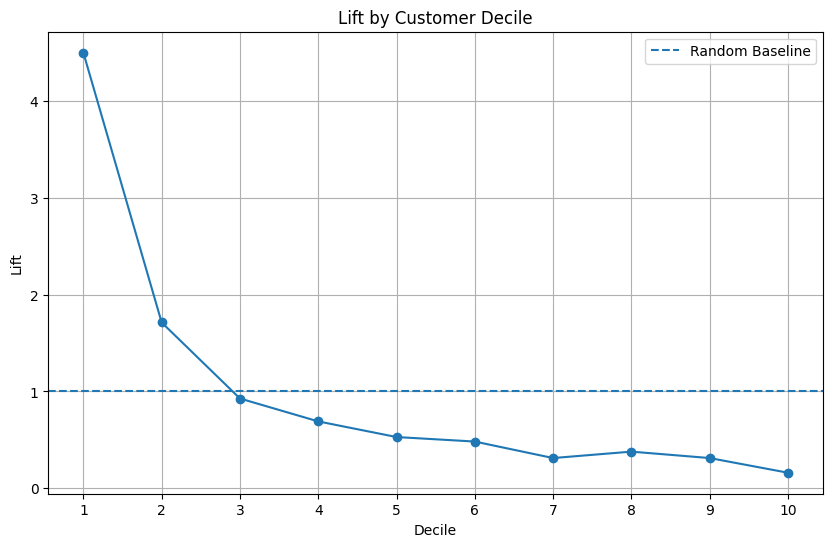

In [179]:
plt.figure(figsize=(10, 6))

plt.plot(
    lift_table["decile"],
    lift_table["lift"],
    marker="o"
)

plt.axhline(
    1,
    linestyle="--",
    label="Random Baseline"
)

plt.xlabel("Decile")
plt.ylabel("Lift")
plt.title("Lift by Customer Decile")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

**On the held-out test set, the top 10% of customers ranked by model score achieved a 52.5% observed conversion rate and captured 44.9% of all subscribers, corresponding to a 4.49× lift over the baseline conversion rate.**

In [182]:
!pip install -q shap

In [184]:
import shap

feature_names = [
    # Numeric
    "age",
    "balance",
    "day",
    "pdays",
    "previous",

    # Binary
    "default",
    "housing",
    "loan",

    # Ordinal
    "education",

    # Job
    "job_admin",
    "job_blue-collar",
    "job_entrepreneur",
    "job_housemaid",
    "job_management",
    "job_retired",
    "job_self-employed",
    "job_services",
    "job_student",
    "job_technician",
    "job_unemployed",
    "job_unknown",

    # Marital
    "marital_divorced",
    "marital_married",
    "marital_single",

    # Contact
    "contact_cellular",
    "contact_telephone",
    "contact_unknown",

    # Poutcome
    "poutcome_failure",
    "poutcome_other",
    "poutcome_success",
    "poutcome_unknown",

    # Month cyclical
    "month_sin",
    "month_cos"
]

print(len(feature_names))

33


In [185]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(
    X_test_prepared
)

print(shap_values.shape)

(9043, 33)


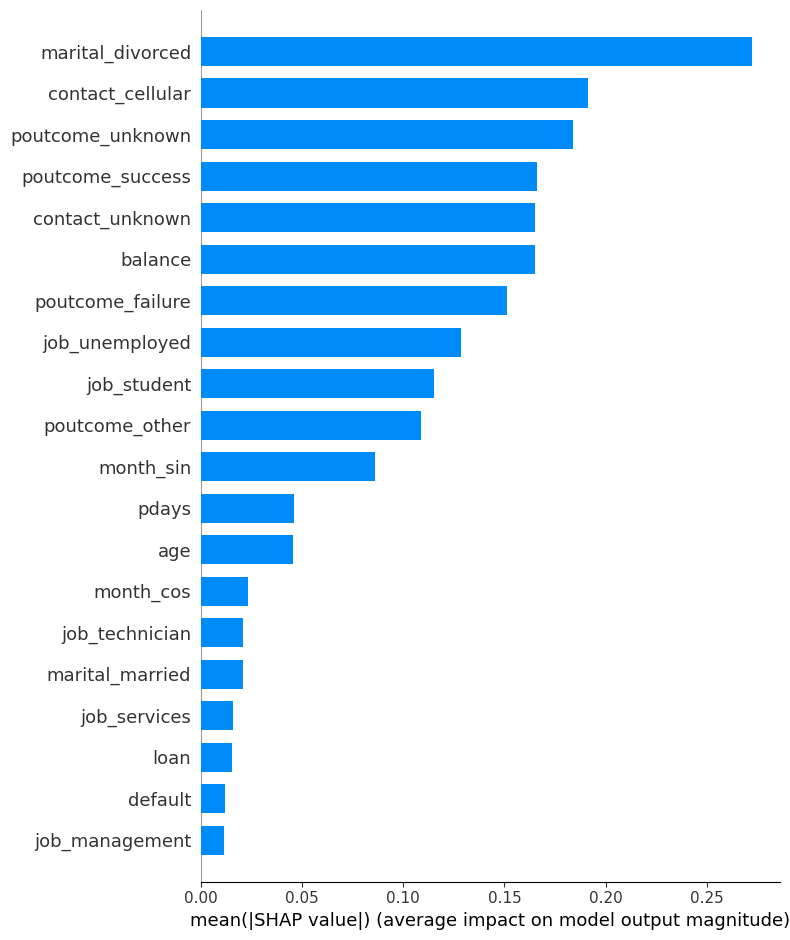

In [186]:
shap.summary_plot(
    shap_values,
    X_test_prepared,
    feature_names=feature_names,
    plot_type="bar"
)

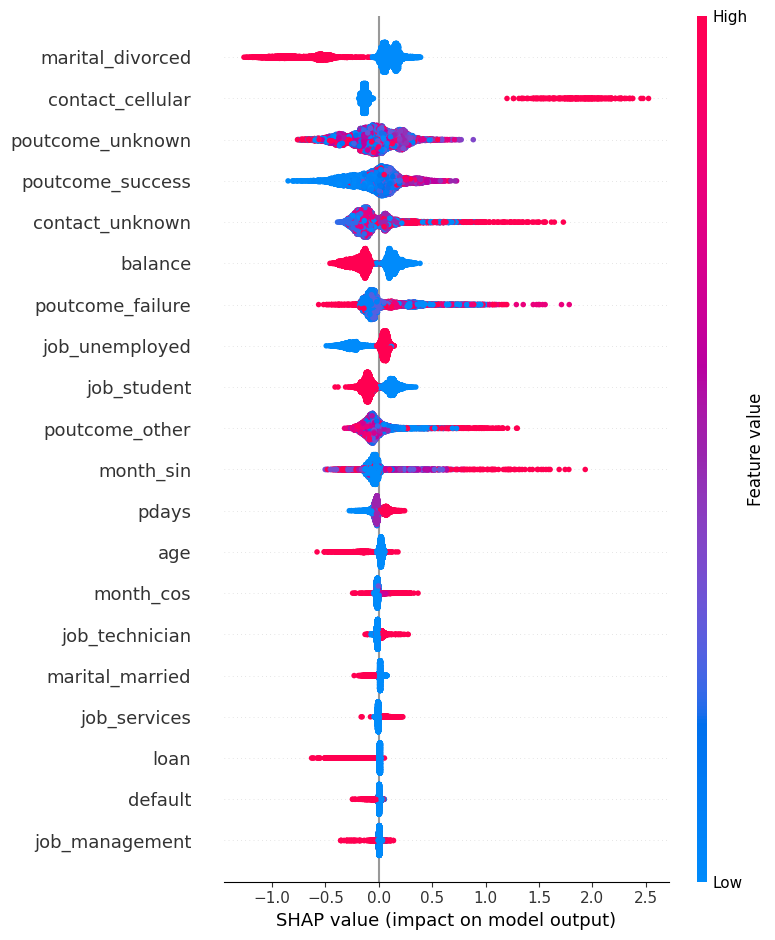

In [187]:
shap.summary_plot(
    shap_values,
    X_test_prepared,
    feature_names=feature_names
)

In [192]:
shap_importance.head(15)

,feature,mean_abs_shap
0,marital_divorced,0.272559
1,contact_cellular,0.191476
2,poutcome_unknown,0.184093
3,poutcome_success,0.166200
4,contact_unknown,0.165039
5,balance,0.165039
6,poutcome_failure,0.151238
7,job_unemployed,0.128753
8,job_student,0.115238
9,poutcome_other,0.108797


In [193]:
# Convert SHAP values into a DataFrame
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

# Get the top 15 features based on mean absolute SHAP
top_features = (
    shap_df.abs()
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Print numerical information for each feature
for feature in top_features:
    print(f"\n{feature}")
    print("Mean SHAP:", shap_df[feature].mean())
    print("Mean |SHAP|:", shap_df[feature].abs().mean())
    print("Min SHAP:", shap_df[feature].min())
    print("Max SHAP:", shap_df[feature].max())


marital_divorced
Mean SHAP: -0.1186059
Mean |SHAP|: 0.2725592
Min SHAP: -1.2633659839630127
Max SHAP: 0.3911368250846863

contact_cellular
Mean SHAP: -0.06502326
Mean |SHAP|: 0.19147563
Min SHAP: -0.18934012949466705
Max SHAP: 2.525587320327759

poutcome_unknown
Mean SHAP: -0.043984316
Mean |SHAP|: 0.18409286
Min SHAP: -0.7623245716094971
Max SHAP: 0.8842564225196838

poutcome_success
Mean SHAP: -0.0286582
Mean |SHAP|: 0.16619955
Min SHAP: -0.8504170179367065
Max SHAP: 0.7278679609298706

contact_unknown
Mean SHAP: -0.04092442
Mean |SHAP|: 0.16503893
Min SHAP: -0.38709011673927307
Max SHAP: 1.7277681827545166

balance
Mean SHAP: -0.040995765
Mean |SHAP|: 0.16503882
Min SHAP: -0.45805734395980835
Max SHAP: 0.3854944705963135

poutcome_failure
Mean SHAP: 0.047196236
Mean |SHAP|: 0.15123801
Min SHAP: -0.5643483996391296
Max SHAP: 1.782996416091919

job_unemployed
Mean SHAP: -0.05510976
Mean |SHAP|: 0.12875283
Min SHAP: -0.49315345287323
Max SHAP: 0.14235776662826538

job_student
Mean SHA

In [194]:
shap_direction = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0),
    "positive_%": (shap_values > 0).mean(axis=0) * 100,
    "negative_%": (shap_values < 0).mean(axis=0) * 100
})

shap_direction = (
    shap_direction
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

shap_direction

,feature,mean_abs_shap,mean_shap,positive_%,negative_%
0,marital_divorced,0.272559,-0.118606,69.479155,30.520845
1,contact_cellular,0.191476,-0.065023,3.383833,96.616167
2,poutcome_unknown,0.184093,-0.043984,43.271038,56.728962
3,poutcome_success,0.166200,-0.028658,49.585315,50.414685
4,contact_unknown,0.165039,-0.040924,30.764127,69.235873
5,balance,0.165039,-0.040996,44.708614,55.291386
6,poutcome_failure,0.151238,0.047196,39.057835,60.942165
7,job_unemployed,0.128753,-0.055110,63.806259,36.193741
8,job_student,0.115238,-0.013635,39.964614,60.035386
9,poutcome_other,0.108797,-0.019902,26.982196,73.017804


In [195]:
import joblib
import numpy as np
import pandas as pd

# Save trained model + preprocessing pipeline
joblib.dump(final_model, "xgb_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

# Save test data + predictions
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["probability"] = y_test_prob
test_results["prediction"] = (y_test_prob >= 0.22).astype(int)

test_results.to_csv("test_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [198]:
from google.colab import files

files.download("xgb_model.pkl")
# files.download("test_results.pkl")
files.download("preprocessor.pkl")
# files.download("rf_val_prob.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>